In [274]:
import pandas as pd
import matplotlib.pyplot as plt
from utils import column2array

#datasets = ['CocitationCora', 'CoauthorshipCora', 'CocitationPubmed']
#models = ['HGNNP', 'UniSAGE', 'UniGCN', 'UniGIN', 'UniGAT', 'HNHN']
dataset = 'CoauthorshipCora'
model = 'HGNNP'
df_results = pd.read_csv(f'Output/g5k/results_{dataset}_{model}.csv', index_col=0)
df_results[(df_results['epochs']==500) & (df_results['depth']==1)].sort_values(by = ['test_accuracy'], ascending = False).head()

,model,data,depth,epochs,best_val_accuracy,test_accuracy,drop_method,drop_rate,oversmoothing,val_accuracy,loss
675,HGNNP,CoauthorshipCora,1,500,0.685748,0.684969,dropedge,0.10,"[0.024898743256926537, 0.06809321790933609, 0....","[0.2936137020587921, 0.295560747385025, 0.3278...","[1.9457379579544067, 1.9257653951644897, 1.884..."
285,HGNNP,CoauthorshipCora,1,500,0.684579,0.684190,dropedge,0.05,"[0.025119466707110405, 0.07045961171388626, 0....","[0.2971183657646179, 0.2982866168022156, 0.360...","[1.9457426071166992, 1.9260430335998535, 1.879..."
415,HGNNP,CoauthorshipCora,1,500,0.684190,0.683801,drophyperedge,0.05,"[0.02434479631483555, 0.06962007284164429, 0.1...","[0.28582555055618286, 0.3006230592727661, 0.33...","[1.9457405805587769, 1.9249402284622192, 1.881..."
1065,HGNNP,CoauthorshipCora,1,500,0.686137,0.683411,dropedge,0.20,"[0.02482631616294384, 0.06481999903917313, 0.1...","[0.2842679023742676, 0.2842679023742676, 0.300...","[1.9457229375839233, 1.928675651550293, 1.8923..."
25,HGNNP,CoauthorshipCora,1,500,0.682632,0.682632,no dropout,0.05,"[0.024886587634682655, 0.07334356009960175, 0....","[0.3006230592727661, 0.29945483803749084, 0.42...","[1.9456205368041992, 1.923575758934021, 1.8741..."


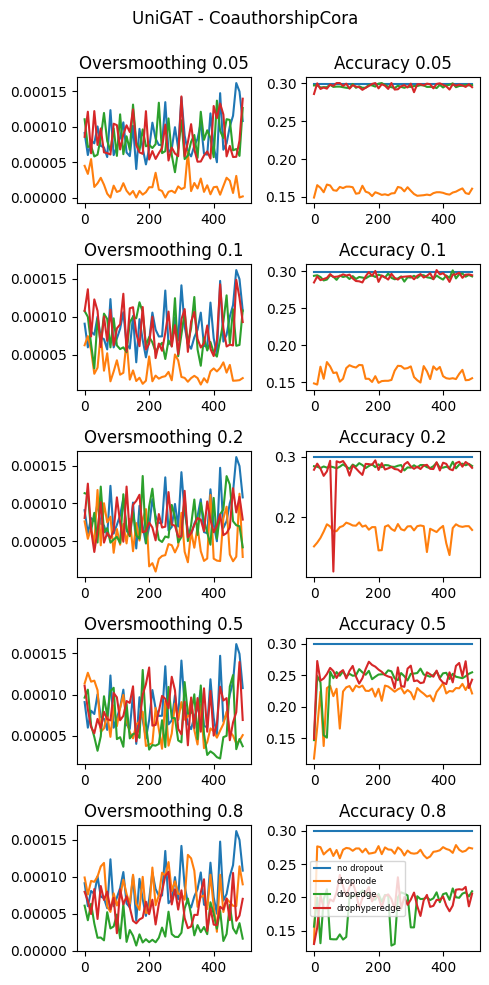

In [221]:
epochs = 500
drop_methods = ['no dropout', 'dropnode', 'dropedge', 'drophyperedge']
drop_rates = [0.05, 0.1, 0.2, 0.5, 0.8]
x_axis = [item * 10 for item in list(range(epochs//10))]
i = 0
depth = 12
results = df_results[(df_results['epochs']== epochs) & (df_results['data']== dataset) & (df_results['model']== model)
                     & (df_results['depth']== depth)]

fig, axes = plt.subplots(len(drop_rates), 2, figsize=(5, 10))

axes = axes.flatten()
test_accuracy = {} # test_accuracy

for drop_rate in drop_rates:
    for method in drop_methods:
        if method == 'no dropout':
            results_smoothing = results[results['drop_method']== method]
            values_smoothing = results_smoothing['oversmoothing'].values[0]
            values_smoothing = column2array(values_smoothing)
            values_accuracy = results_smoothing['val_accuracy'].values[0]
            values_accuracy = column2array(values_accuracy)
            
            axes[i].plot(x_axis, values_smoothing, label = method)  
            axes[i].set_title(f"Oversmoothing{drop_rate}")
            
            axes[i+1].plot(x_axis, values_accuracy, label = method)  
            axes[i+1].set_title(f"Accuracy {drop_rate}")
            
        else:
            
            results_smoothing = results[results['drop_method']== method]
            values_smoothing = results_smoothing[results_smoothing['drop_rate']== drop_rate]['oversmoothing'].values[0]
            values_smoothing = column2array(values_smoothing)
            values_accuracy = results_smoothing[results_smoothing['drop_rate']== drop_rate]['val_accuracy'].values[0]
            values_accuracy = column2array(values_accuracy)
            
            axes[i].plot(x_axis, values_smoothing, label = method)  
            axes[i].set_title(f"Oversmoothing {drop_rate}")
            
            axes[i+1].plot(x_axis, values_accuracy, label = method)  
            axes[i+1].set_title(f"Accuracy {drop_rate}")
    i += 2
 
plt.legend(prop={'size': 6}, title_fontsize=6)
plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.suptitle(f"{model} - {dataset}")
plt.show()

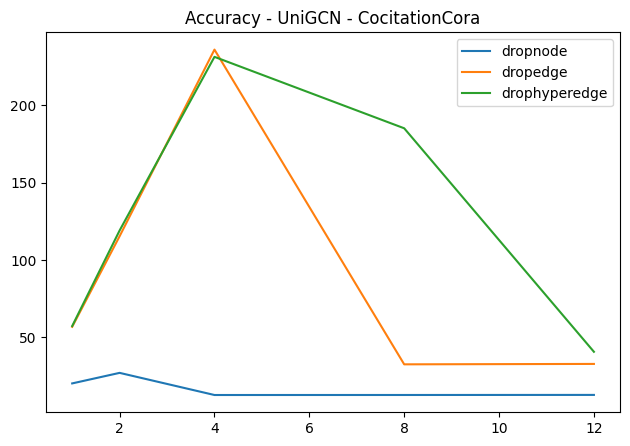

In [273]:
epochs = 500
drop_methods = ['no dropout', 'dropnode', 'dropedge', 'drophyperedge']
drop_rates = [0.05, 0.1, 0.2, 0.5, 0.8]
depths = [1, 2, 4, 8, 12]
x_axis = [item * 10 for item in list(range(epochs//10))]
i = 0
depth = 12
drop_rate = 0.5
#datasets = ['CocitationCora', 'CoauthorshipCora', 'CocitationPubmed']
#models = ['HGNNP', 'UniSAGE', 'UniGCN', 'UniGIN', 'UniGAT', 'HNHN']
dataset = 'CocitationCora'
model = 'UniGCN'
df_results = pd.read_csv(f'Output/g5k/results_{dataset}_{model}.csv', index_col=0)

results = df_results[(df_results['epochs']== epochs) & (df_results['data']== dataset) & (df_results['model']== model)
                     & (df_results['drop_rate']== drop_rate)]


test_accuracy = {} # test_accuracy
smoothing = {}
for method in drop_methods:
    test_accuracy[method] = []
    smoothing[method] = []

for method in drop_methods:
    if method == 'no dropout':
        continue
        results_smoothing = column2array(results[results['drop_method']== method]['oversmoothing'].values[0])[-1]
        smoothing[method].append(results_smoothing)

        results_accuracy = results[results['drop_method']== method]['test_accuracy'].values
        test_accuracy[method].append(results_accuracy)

    else:
        results_smoothing = results[results['drop_method']== method]['oversmoothing'].values
        results_smoothing = [sum(column2array(k)) for k in results_smoothing]
        smoothing[method].append(results_smoothing)

        results_accuracy = results[results['drop_method']== method]['test_accuracy'].values
        test_accuracy[method].append(results_accuracy)
        
        
    i += 2

for method in drop_methods:
    if method != 'no dropout':
        plt.plot(depths, smoothing[method][0], label = method)
plt.title(f"Accuracy - {model} - {dataset}")
plt.legend()
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

0.000107970779936295
[0.29945484]
1.6265923932223814e-06
[0.16121495 0.16900311 0.18224299 0.23325545 0.27219626]
0.00012627984688151628
[0.29711837 0.29244548 0.28699377 0.25077882 0.20015576]
0.00013940662029199302
[0.29205608 0.28699377 0.27803737 0.24454829 0.17640187]
{'no dropout': [0.000107970779936295], 'dropnode': [1.6265923932223814e-06], 'dropedge': [0.00012627984688151628], 'drophyperedge': [0.00013940662029199302]}


ValueError: x and y must have same first dimension, but have shapes (5,) and (1,)

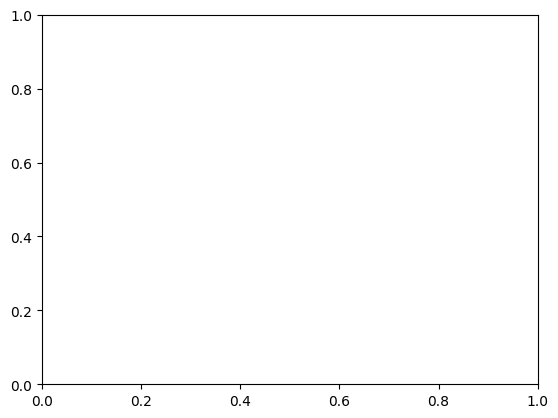

In [237]:
epochs = 500
drop_methods = ['no dropout', 'dropnode', 'dropedge', 'drophyperedge']
drop_rates = [0.05, 0.1, 0.2, 0.5, 0.8]
x_axis = [item * 10 for item in list(range(epochs//10))]
i = 0
depth = 12
results = df_results[(df_results['epochs']== epochs) & (df_results['data']== dataset) & (df_results['model']== model)
                     & (df_results['depth']== depth)]


test_accuracy = {} # test_accuracy
smoothing = {}
for method in drop_methods:
    test_accuracy[method] = []
    smoothing[method] = []

for method in drop_methods:
    if method == 'no dropout':
        results_smoothing = column2array(results[results['drop_method']== method]['oversmoothing'].values[0])[-1]
        print(results_smoothing)
        smoothing[method].append(results_smoothing)
        results_accuracy = results[results['drop_method']== method]['test_accuracy'].values
        print(results_accuracy)
        test_accuracy[method].append(results_accuracy)

    else:
        results_smoothing = column2array(results[results['drop_method']== method]['oversmoothing'].values[0])[-1]
        print(results_smoothing)
        smoothing[method].append(results_smoothing)
        results_accuracy = results[results['drop_method']== method]['test_accuracy'].values
        print(results_accuracy)
        test_accuracy[method].append(results_accuracy)
        
        
    i += 2
print(smoothing)

for method in drop_methods:
    if method != 'no dropout':
        plt.plot(drop_rates, smoothing[method][0], label = method)
plt.title(f"Accuracy - {model} - {dataset}")
plt.legend()
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()